---
# Modelación Actuarial de Riesgos para Seguro de Casa Habitación

> **Dataset:** `[BASE_SESA_FV]`  
> **Fecha:** `[Mayo 2026]`  
> **Autor:** `[Seguros de Daños Bouclier]`

---
# Índice

**1.** [Definición del producto](#1-definición-del-producto)  
**2.** [Análisis de información inicial](#2-análisis-de-información-inicial)  
**3.** [Prima y cuota de riesgo](#3-prima-y-cuota-de-riesgo)  
**4.** [Cálculo de la cuota de riesgo en función de deducible fijo](#4-cálculo-de-la-cuota-de-riesgo-en-función-de-deducible-fijo)  
**5.** [Procedimientos de la prima de tarifa](#5-procedimientos-de-la-prima-de-tarifa)  
**6.** [Cálculo de la cuota de riesgo en función del estado](#6-cálculo-de-la-cuota-de-riesgo-en-función-del-estado)  


---
## 1. Definición del producto

<table style="border-collapse: collapse; width: 100%;">

<tr style="background-color:#1f2937; color:white;">
    <th style="border:1px solid black; padding:8px;">CAMPO</th>
    <th style="border:1px solid black; padding:8px;">FILTRO SELECCIÓN</th>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">MONEDA</td>
    <td style="border:1px solid black; padding:8px;">Nacional</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">FORMA DE VENTAS</td>
    <td style="border:1px solid black; padding:8px;">TODAS</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">GIRO DE LA UBICACIÓN</td>
    <td style="border:1px solid black; padding:8px;">Casa Habitación</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">NÚMERO DE NIVELES</td>
    <td style="border:1px solid black; padding:8px;">TODOS</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">TIPO PRIMER RIESGO</td>
    <td style="border:1px solid black; padding:8px;">Ninguno</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">ENTIDAD</td>
    <td style="border:1px solid black; padding:8px;">Territorio Nacional</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">SUBTIPO DE SEGURO</td>
    <td style="border:1px solid black; padding:8px;">TODOS</td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">TIPO DE BIEN</td>
    <td style="border:1px solid black; padding:8px;">
        Contenidos; Contenidos y Edificio; Edificio
    </td>
</tr>

<tr>
    <td style="border:1px solid black; padding:8px;">COBERTURAS</td>
    <td style="border:1px solid black; padding:8px;">
        Incendio, rayo y explosión; Remoción de Escombros; 
        Gastos Extras para Casa Habitación; Todo riesgo
    </td>
</tr>

</table>

---
## 2. Análisis de información inicial

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import (expon, lognorm, gamma, weibull_min,kstest)


# Ruta del archivo Excel
ruta_excel = "BASE_SESA_FV.xlsx"

# Leer únicamente las hojas necesarias
hojas = ["Emisión", "Suma Asegurada", "Siniestros"]

dfs = pd.read_excel(ruta_excel,sheet_name=hojas)

# Guardar cada hoja en un DataFrame independiente
df_emision = dfs["Emisión"]
df_suma_asegurada = dfs["Suma Asegurada"]
df_siniestros = dfs["Siniestros"]

df_emision.info()
df_suma_asegurada.info()
df_siniestros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12627 entries, 0 to 12626
Data columns (total 19 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   MONEDA                                    12627 non-null  object 
 1   FORMA DE VENTA                            12627 non-null  object 
 2   GIRO DE LA UBICACIÓN                      12627 non-null  object 
 3   ENTIDAD                                   12627 non-null  object 
 4   SUBTIPO DE SEGURO                         12627 non-null  object 
 5   NÚMERO DE NIVELES                         12627 non-null  int64  
 6   TIPO PRIMER RIESGO                        12627 non-null  object 
 7   NÚMERO DE UBICACIONES                     12627 non-null  int64  
 8   PRIMA EMITIDA                             12627 non-null  float64
 9   PRIMA RETENIDA                            12627 non-null  float64
 10  PRIMA DEVENGADA EN EL EJERCICIO   

In [4]:
# ============================================
# TABLA RESUMEN 1
# ============================================

# Copias
emision = df_emision.copy()

suma = df_suma_asegurada.copy()

siniestros = df_siniestros.copy()

# Años 
anios = [2020, 2021, 2022, 2023, 2024]

# Filtros
filtro_suma = suma[
    
    # Giro
    suma["GIRO"].astype(str).str.contains(
        "Casa",
        case=False,
        na=False
    ) &
    
    # Tipo de primer riesgo
    suma["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning",
        case=False,
        na=False
    ) &
    
    # Tipo de bien
    suma["TIPO DE BIEN"].astype(str).str.contains(
        "Contenidos|Edificio",
        case=False,
        na=False
    ) &
    
    # Coberturas
    suma["COBERTURA "].astype(str).str.contains(
    "Incendio|Remoción|Gastos Extras|Todo riesgo",
    case=False,
    na=False
    )

]


# Creamos la tabla

filas = []

# Coberturas
coberturas_reales = filtro_suma["COBERTURA "].unique()

# Tipos de bienes
tipos_bien_reales = filtro_suma["TIPO DE BIEN"].unique()

for cobertura in coberturas_reales:
    
    for tipo in tipos_bien_reales:
        
        temp = filtro_suma[
            (filtro_suma["COBERTURA "] == cobertura) &
            (filtro_suma["TIPO DE BIEN"] == tipo)
        ]
        
        # Si no hay datos, pasamos al siguiente
        if temp.empty:
            continue
        
        fila = {"COBERTURA": cobertura,"TIPO DE BIEN": tipo}
    
        # Ubicaciones
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "NÚMERO DE UBICACIONES"
            ].sum()
            
            fila[f"UBICACIONES_{anio}"] = valor
        
        fila["UBICACIONES_TOTAL"] = temp[
            "NÚMERO DE UBICACIONES"
        ].sum()
        
        # Suma asegurada
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "SUMA ASEGURADA"
            ].sum()
            
            fila[f"SA_{anio}"] = valor
        
        fila["SA_TOTAL"] = temp[
            "SUMA ASEGURADA"
        ].sum()
        
        # Suma asegurada expuesta
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "SUMA ASEGURADA EXPUESTA"
            ].sum()
            
            fila[f"SAE_{anio}"] = valor
        
        fila["SAE_TOTAL"] = temp[
            "SUMA ASEGURADA EXPUESTA"
        ].sum()
        
        filas.append(fila)

# Dataframe 

df_reporte_superior = pd.DataFrame(filas)
pd.set_option("display.max_columns", None)
display(df_reporte_superior)

,COBERTURA,TIPO DE BIEN,UBICACIONES_2020,UBICACIONES_2021,UBICACIONES_2022,UBICACIONES_2023,UBICACIONES_2024,UBICACIONES_TOTAL,SA_2020,SA_2021,SA_2022,SA_2023,SA_2024,SA_TOTAL,SAE_2020,SAE_2021,SAE_2022,SAE_2023,SAE_2024,SAE_TOTAL
0,Todo Riesgo,Edificio,401397,351761,364477,367217,365202,1850054,1321521263431,22540824759036,8257548810013,1838823609973,1951295666569,35910014109022,1020844721001,4319133894937,2245706417767,1377501659025,1402684168984,10365870861714
1,Todo Riesgo,Contenidos,424957,391011,372935,413895,412438,2015236,305532669246,7021838940858,3096658231891,432298142967,448587343329,11304915328291,186387817482,654534793558,738681495644,309724410254,318520807026,2207849323964
2,Todo Riesgo,Contenidos y Edificio,28,16,33,71,12251,12399,1041274419,664832140,2534998750,5375080411,34343616282,43959802002,1040608425,664832140,2652307616,5345149387,33956698696,43659596264
3,"Incendio, rayo y explosión",Edificio,674690,1266418,513799,619481,410535,3484923,2793987430513,23643825276204,8755665297336,2318477460523,2350781624335,39862737088911,82050733170589,3038706556549,2532780537490,1789763637787,1759888022033,91171871924448
4,"Incendio, rayo y explosión",Contenidos,673861,573226,520277,508634,429601,2705599,1909080038558,8058002896332,3681590885260,741766090691,620481592950,15010921503791,47626663545285,1290802007037,1135880723238,606890864179,480491800134,51140728939873
5,"Incendio, rayo y explosión",Contenidos y Edificio,417,213,358,317,350,1655,6024289932,3228233532,8164429259,13433523821,22232203505,53082680049,6149304807,3244809962,8332129337,12455496851,17972606512,48154347469
6,Remoción de Escombros,Edificio,152349,123960,154744,91828,64579,587460,32424895055,27789775140,51238063678,25800918313,47791198424,185044850610,8062054911268,22805032835,42647434780,19132409006,39503160104,8186142947993
7,Remoción de Escombros,Contenidos,215404,184276,179007,149236,120926,848849,15977877517,12859315909,15110388920,10601559556,13038531019,67587672921,4679820378959,11609587186,13558079553,8974201388,11118637918,4725080885004
8,Gastos Extras para Casa Habitación,Edificio,2,2,0,0,0,4,995436,1023360,0,0,0,2018796,995436,1023360,0,0,0,2018796
9,Gastos Extras para Casa Habitación,Contenidos,1895,3976,31217,5127,4320,46535,99323618,195416157,690110756,458519589,449263813,1892633933,95942518,192352389,684736280,451708746,443882851,1868622784


In [5]:
# ============================================
# TABLA RESUMEN 2
# ============================================

# Filtro de siniestros

filtro_siniestros = siniestros[
    
    # MONEDA
    siniestros["MONEDA"].astype(str).str.contains(
        "Nacional",
        case=False,
        na=False
    ) &
    
    # Giro
    siniestros["GIRO LA UBICACIÓN"].astype(str).str.contains(
        "Casa",
        case=False,
        na=False
    ) &
    
    # Tipo de primer riesgo
    siniestros["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning",
        case=False,
        na=False
    ) &
    
    # Tipo de bien
    siniestros["TIPO DE BIEN"].astype(str).str.contains(
        "Contenidos|Edificio",
        case=False,
        na=False
    ) &
    
    # Cobertura
    siniestros["COBERTURA"].astype(str).str.contains(
        "Incendio|Remoción|Gastos Extras|Todo riesgo",
        case=False,
        na=False
    )
]

# Creamos la tabla

filas_sin = []

coberturas_sin = filtro_siniestros["COBERTURA"].unique()

tipos_sin = filtro_siniestros["TIPO DE BIEN"].unique()

for cobertura in coberturas_sin:
    
    for tipo in tipos_sin:
        
        temp = filtro_siniestros[
            (filtro_siniestros["COBERTURA"] == cobertura) &
            (filtro_siniestros["TIPO DE BIEN"] == tipo)
        ]
        
        if temp.empty:
            continue
        
        fila = {"COBERTURA": cobertura,"TIPO DE BIEN": tipo}
        
        # Siniestros
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "NÚMERO DE SINIESTROS"
            ].sum()
            
            fila[f"SINIESTROS_{anio}"] = valor
        
        fila["SINIESTROS_TOTAL"] = temp[
            "NÚMERO DE SINIESTROS"
        ].sum()
        
        # Monto pagado
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "MONTO PAGADO"
            ].sum()
            
            fila[f"PAGADO_{anio}"] = valor
        
        fila["PAGADO_TOTAL"] = temp[
            "MONTO PAGADO"
        ].sum()
        
        # Mondo del siniestro
        
        for anio in anios:
            
            valor = temp.loc[
                temp["AÑO"] == anio,
                "MONTO DE SINIESTRO"
            ].sum()
            
            fila[f"OCURRIDO_{anio}"] = valor
        
        fila["OCURRIDO_TOTAL"] = temp[
            "MONTO DE SINIESTRO"
        ].sum()
        
        filas_sin.append(fila)

# Dataframe

df_siniestros_resumen = pd.DataFrame(filas_sin)
display(df_siniestros_resumen)

,COBERTURA,TIPO DE BIEN,SINIESTROS_2020,SINIESTROS_2021,SINIESTROS_2022,SINIESTROS_2023,SINIESTROS_2024,SINIESTROS_TOTAL,PAGADO_2020,PAGADO_2021,PAGADO_2022,PAGADO_2023,PAGADO_2024,PAGADO_TOTAL,OCURRIDO_2020,OCURRIDO_2021,OCURRIDO_2022,OCURRIDO_2023,OCURRIDO_2024,OCURRIDO_TOTAL
0,"Incendio, rayo y explosión",Edificio,1448,1696,1705,1817,2018,8684,39613237.40,76745014.07,77540514.88,66314143.43,79179491.06,3.393924e+08,58094959.11,1.140229e+08,5.684219e+08,1.265256e+08,96142490.29,9.632079e+08
1,"Incendio, rayo y explosión",Contenidos,701,867,837,933,976,4314,14152908.67,41559932.44,69112734.74,12522627.80,18613666.37,1.559619e+08,21897151.83,9.443331e+07,2.683600e+07,1.743615e+07,26366757.82,1.869694e+08
2,"Incendio, rayo y explosión",Contenidos y Edificio,4,1,1,0,1,7,89604.93,78469.80,27450.00,0.00,0.00,1.955247e+05,251050.10,2.153020e+04,2.745000e+04,0.000000e+00,27010.00,3.270403e+05
3,Todo Riesgo,Edificio,1675,2586,2365,3412,4359,14397,24082220.59,37815696.31,39546266.88,47610889.89,56059770.43,2.051148e+08,30918506.41,1.205034e+08,4.697551e+07,6.088405e+07,66284228.64,3.255657e+08
4,Todo Riesgo,Contenidos,710,860,882,834,1034,4320,8049704.76,11816879.11,9358015.12,18132470.12,15675750.58,6.303282e+07,11346569.02,1.414816e+07,1.274575e+07,2.159158e+07,19699208.03,7.953127e+07
5,Todo Riesgo,Contenidos y Edificio,0,0,0,1,32,33,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.000000e+00,0.000000e+00,4.417375e+04,72414.51,1.165883e+05
6,Remoción de Escombros,Edificio,38,36,32,51,179,336,547158.54,600110.04,1415858.85,1409319.14,3608496.01,7.580943e+06,659853.07,7.534208e+05,1.580495e+06,2.693383e+06,5887873.15,1.157503e+07
7,Remoción de Escombros,Contenidos,2,3,4,7,7,23,21647.50,27600.00,33580.00,164854.70,191555.49,4.392377e+05,21647.50,2.956700e+04,5.103000e+04,2.834497e+05,278430.49,6.641247e+05
8,Gastos Extras para Casa Habitación,Edificio,1,0,2,1,0,4,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.000000e+00,3.000000e+03,3.000000e+03,0.00,6.000000e+03
9,Gastos Extras para Casa Habitación,Contenidos,0,0,1,1,0,2,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.000000e+00,7.000000e+03,7.000000e+03,0.00,1.400000e+04


In [6]:
# ============================================
# TABLA RESUMEN 3
# ============================================

# Filtro emisión

filtro_emision = emision[
    
    # Giro
    emision["GIRO DE LA UBICACIÓN"].astype(str).str.contains(
        "Casa",
        case=False,
        na=False
    ) &
    
    # Tipo de primer riesgo
    emision["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning",
        case=False,
        na=False
    )
].copy()

# Clasificamos por tipo de bien

def clasificar_tipo_bien(row):
    
    edificio = row["VALORES TOTALES EDIFICIO"]
    contenido = row["VALORES TOTALES CONTENIDO"]
    
    # Validamos nulos
    
    edificio = 0 if pd.isna(edificio) else edificio
    
    contenido = 0 if pd.isna(contenido) else contenido
    
    if edificio > 0 and contenido > 0:
        return "Contenidos y Edificio"
    
    elif edificio > 0:
        return "Edificio"
    
    elif contenido > 0:
        return "Contenidos"
    
    else:
        return "Sin Clasificar"

# Creamos como columna nueva

filtro_emision["TIPO DE BIEN"] = filtro_emision.apply(
    clasificar_tipo_bien,
    axis=1
)

# Filtramos 

filtro_emision_tb = filtro_emision[
    filtro_emision["TIPO DE BIEN"].isin([
        "Contenidos",
        "Edificio",
        "Contenidos y Edificio"
    ])
]

# Creamos la tabla

filas_emi = []

tipos_bien = [
    "Contenidos",
    "Edificio",
    "Contenidos y Edificio"
]

for tipo in tipos_bien:
    
    temp = filtro_emision_tb[
        filtro_emision_tb["TIPO DE BIEN"] == tipo
    ]
    
    # Si no hay datos
    
    if temp.empty:
        continue
    
    fila = {"TIPO DE BIEN": tipo}
    
    # Prima emitida
    
    for anio in anios:
        
        valor = temp.loc[
            temp["AÑO"] == anio,
            "PRIMA EMITIDA"
        ].sum()
        
        fila[f"PRIMA_{anio}"] = valor
    
    fila["PRIMA_TOTAL"] = temp[
        "PRIMA EMITIDA"
    ].sum()
    
    # Prima devengada
    
    for anio in anios:
        
        valor = temp.loc[
            temp["AÑO"] == anio,
            "PRIMA DEVENGADA EN EL EJERCICIO"
        ].sum()
        
        fila[f"DEVENGADA_{anio}"] = valor
    
    fila["DEVENGADA_TOTAL"] = temp[
        "PRIMA DEVENGADA EN EL EJERCICIO"
    ].sum()
    
    # Numero de ubicaciones
    
    for anio in anios:
        
        valor = temp.loc[
            temp["AÑO"] == anio,
            "NÚMERO DE UBICACIONES"
        ].sum()
        
        fila[f"UBICACIONES_{anio}"] = valor
    
    fila["UBICACIONES_TOTAL"] = temp[
        "NÚMERO DE UBICACIONES"
    ].sum()
    
    filas_emi.append(fila)

# Dataframe

df_primas_resumen = pd.DataFrame(filas_emi)

pd.set_option(
    "display.max_columns",
    None
)

display(df_primas_resumen)

,TIPO DE BIEN,PRIMA_2020,PRIMA_2021,PRIMA_2022,PRIMA_2023,PRIMA_2024,PRIMA_TOTAL,DEVENGADA_2020,DEVENGADA_2021,DEVENGADA_2022,DEVENGADA_2023,DEVENGADA_2024,DEVENGADA_TOTAL,UBICACIONES_2020,UBICACIONES_2021,UBICACIONES_2022,UBICACIONES_2023,UBICACIONES_2024,UBICACIONES_TOTAL
0,Contenidos,9.574471e+07,1.462234e+06,1.383094e+06,4.118991e+07,3.269154e+07,1.724715e+08,9.682032e+07,1.457146e+06,1.363787e+06,4.125287e+07,3.276138e+07,1.736555e+08,243,291,335,623,1008,2500
1,Edificio,3.325323e+05,6.794610e+05,3.922251e+05,1.385296e+06,7.089436e+05,3.498458e+06,2.641098e+05,4.953106e+05,1.912871e+05,9.219194e+05,9.054276e+05,2.778055e+06,471,543,1334,1046,309,3703
2,Contenidos y Edificio,4.401477e+08,6.060010e+08,4.793480e+08,4.752893e+08,4.977067e+08,2.498493e+09,3.880393e+08,6.265569e+08,4.737261e+08,4.992765e+08,4.962863e+08,2.483885e+09,802135,1506085,681801,799890,598294,4388205


---
## 3. Prima y cuota de riesgo

### Metodología de Frecuencia, Severidad y Prima de Riesgo

La información presentada en las tablas siguientes se obtiene mediante una selección y discriminación de información con el objetivo de desarrollar la Nota Técnica del producto, permitiendo un adecuado orden y selección del riesgo.

### Frecuencia

La frecuencia representa la proporción de siniestros respecto al número de ubicaciones expuestas al riesgo.

$$
Frecuencia_{i,j} =
\frac{
\text{Número de Siniestros}_{i,j}
}{
\text{Número de Ubicaciones}_{i,j}
}
$$

Donde:

- $i$: Año
- $j$: Tipo de Bien / Cobertura

---

### Severidad

La severidad se calcula considerando tanto la siniestralidad ocurrida como la siniestralidad pagada, con el objetivo de evaluar la mejor aproximación para la estimación del costo del riesgo.

#### Severidad Ocurrida

$$
Severidad_{Ocurrida,i,j} =
\frac{
\text{Monto de Siniestros Ocurridos}_{i,j}
}{
\text{Número de Siniestros}_{i,j}
}
$$

#### Severidad Pagada

$$
Severidad_{Pagada,i,j} =
\frac{
\text{Monto de Siniestros Pagados}_{i,j}
}{
\text{Número de Siniestros}_{i,j}
}
$$

---

### Prima de Riesgo

Finalmente, se obtiene la Prima de Riesgo mediante el producto de la frecuencia y la severidad.

#### Prima de Riesgo Ocurrida

$$
PR_{Ocurrida,i,j} =
Frecuencia_{i,j}
\cdot
Severidad_{Ocurrida,i,j}
$$

#### Prima de Riesgo Pagada

$$
PR_{Pagada,i,j} =
Frecuencia_{i,j}
\cdot
Severidad_{Pagada,i,j}
$$

Donde:

$$
PR_{tip,i}
$$

representa la prima de riesgo considerando siniestralidad ocurrida o siniestralidad pagada.

---

### Cuota de Riesgo (al millar)

La Cuota de Riesgo considera la relación entre el monto de siniestros y la suma asegurada expuesta.

#### Cuota de Riesgo Ocurrida

$$
CR_{Ocurrida,i,j} =
\frac{
\text{Monto de Siniestros Ocurridos}_{i,j}
}{
\text{Suma Asegurada Expuesta}_{i,j}
}
\cdot 1000
$$

#### Cuota de Riesgo Pagada

$$
CR_{Pagada,i,j} =
\frac{
\text{Monto de Siniestros Pagados}_{i,j}
}{
\text{Suma Asegurada Expuesta}_{i,j}
}
\cdot 1000
$$

---

### Selección de Cuota de Riesgo

Finalmente, se realiza la selección de la cuota de riesgo máxima entre la ocurrida y la pagada.

$$
CR_i =
\max
\left\{
CR_{Ocurrida,i,j},
\,
CR_{Pagada,i,j}
\right\}
$$

In [7]:
# ============================================
# CALCULO DE FRECUENCIA, SEVERIDAD,
# PRIMA DE RIESGO Y CUOTA DE RIESGO
# ============================================

# Creamos la tabla base

base = pd.merge(
    df_reporte_superior,
    df_siniestros_resumen,
    on=["COBERTURA", "TIPO DE BIEN"],
    how="left"
)

# Cálculos

filas_metricas = []

for _, row in base.iterrows():
    
    fila = {
        "COBERTURA": row["COBERTURA"],
        "TIPO DE BIEN": row["TIPO DE BIEN"]
    }
    
    for anio in anios:
        
        # Variables
        
        ubicaciones = row.get(f"UBICACIONES_{anio}", 0)
        
        num_sin = row.get(f"SINIESTROS_{anio}", 0)
        
        ocurrido = row.get(f"OCURRIDO_{anio}", 0)
        
        pagado = row.get(f"PAGADO_{anio}", 0)
        
        sae = row.get(f"SAE_{anio}", 0)
        
        # Frecuencia
        
        frecuencia = (
            num_sin / ubicaciones
            if ubicaciones != 0
            else 0
        )
        
        # Severidad
        
        severidad_ocurrida = (
            ocurrido / num_sin
            if num_sin != 0
            else 0
        )
        
        severidad_pagada = (
            pagado / num_sin
            if num_sin != 0
            else 0
        )
        
        # Prima de riesgo
        
        pr_ocurrida = (
            frecuencia * severidad_ocurrida
        )
        
        pr_pagada = (
            frecuencia * severidad_pagada
        )
        
        # Cuota de riesgo
        
        cr_ocurrida = (
            (ocurrido / sae) * 1000
            if sae != 0
            else 0
        )
        
        cr_pagada = (
            (pagado / sae) * 1000
            if sae != 0
            else 0
        )
        
        cr_max = max(
            cr_ocurrida,
            cr_pagada
        )
        
        # Guardamos resultados
        
        fila[f"FRECUENCIA_{anio}"] = frecuencia
        
        fila[f"SEV_OCURRIDA_{anio}"] = severidad_ocurrida
        
        fila[f"SEV_PAGADA_{anio}"] = severidad_pagada
        
        fila[f"PR_OCURRIDA_{anio}"] = pr_ocurrida
        
        fila[f"PR_PAGADA_{anio}"] = pr_pagada
        
        fila[f"CR_OCURRIDA_{anio}"] = cr_ocurrida
        
        fila[f"CR_PAGADA_{anio}"] = cr_pagada
        
        fila[f"CR_MAX_{anio}"] = cr_max
    
    filas_metricas.append(fila)

# Dataframe

df_metricas = pd.DataFrame(filas_metricas)
display(df_metricas)

,COBERTURA,TIPO DE BIEN,FRECUENCIA_2020,SEV_OCURRIDA_2020,SEV_PAGADA_2020,PR_OCURRIDA_2020,PR_PAGADA_2020,CR_OCURRIDA_2020,CR_PAGADA_2020,CR_MAX_2020,FRECUENCIA_2021,SEV_OCURRIDA_2021,SEV_PAGADA_2021,PR_OCURRIDA_2021,PR_PAGADA_2021,CR_OCURRIDA_2021,CR_PAGADA_2021,CR_MAX_2021,FRECUENCIA_2022,SEV_OCURRIDA_2022,SEV_PAGADA_2022,PR_OCURRIDA_2022,PR_PAGADA_2022,CR_OCURRIDA_2022,CR_PAGADA_2022,CR_MAX_2022,FRECUENCIA_2023,SEV_OCURRIDA_2023,SEV_PAGADA_2023,PR_OCURRIDA_2023,PR_PAGADA_2023,CR_OCURRIDA_2023,CR_PAGADA_2023,CR_MAX_2023,FRECUENCIA_2024,SEV_OCURRIDA_2024,SEV_PAGADA_2024,PR_OCURRIDA_2024,PR_PAGADA_2024,CR_OCURRIDA_2024,CR_PAGADA_2024,CR_MAX_2024
0,Todo Riesgo,Edificio,0.004173,18458.809797,14377.445128,77.027248,59.996015,0.030287,0.023590,0.030287,0.007352,46598.377355,14623.239099,342.571814,107.503948,0.027900,0.008755,0.027900,0.006489,19862.793416,16721.465911,128.884693,108.501406,0.020918,0.017610,0.020918,0.009292,17844.095185,13953.953661,165.798568,129.653284,0.044199,0.034563,0.044199,0.011936,15206.292416,12860.695212,181.500180,153.503460,0.047255,0.039966,0.047255
1,Todo Riesgo,Contenidos,0.001671,15981.083127,11337.612338,26.700511,18.942398,0.060876,0.043188,0.060876,0.002199,16451.351860,13740.557105,36.183541,30.221347,0.021616,0.018054,0.021616,0.002365,14450.960533,10609.994467,34.176860,25.092885,0.017255,0.012669,0.017255,0.002015,25889.189580,21741.570887,52.166816,43.809348,0.069712,0.058544,0.069712,0.002507,19051.458443,15160.300368,47.762835,38.007532,0.061846,0.049214,0.061846
2,Todo Riesgo,Contenidos y Edificio,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014085,44173.750000,0.000000,622.165493,0.000000,0.008264,0.000000,0.008264,0.002612,2262.953437,0.000000,5.910906,0.000000,0.002133,0.000000,0.002133
3,"Incendio, rayo y explosión",Edificio,0.002146,40120.828115,27357.208149,86.106151,58.713242,0.000708,0.000483,0.000708,0.001339,67230.507058,45250.597919,90.035786,60.600066,0.037524,0.025256,0.037524,0.003318,333385.269413,45478.307848,1106.311776,150.916049,0.224426,0.030615,0.224426,0.002933,69634.350391,36496.501613,204.244544,107.047905,0.070694,0.037052,0.070694,0.004916,47642.462978,39236.615986,234.188292,192.869039,0.054630,0.044991,0.054630
4,"Incendio, rayo y explosión",Contenidos,0.001040,31237.021155,20189.598673,32.495057,21.002712,0.000460,0.000297,0.000460,0.001512,108919.619377,47935.331534,164.740103,72.501827,0.073159,0.032197,0.073159,0.001609,32062.120848,82571.965042,51.580207,132.838343,0.023626,0.060845,0.060845,0.001834,18688.267567,13421.894748,34.280354,24.620115,0.028730,0.020634,0.028730,0.002272,27015.120717,19071.379477,61.374992,43.327800,0.054875,0.038739,0.054875
5,"Incendio, rayo y explosión",Contenidos y Edificio,0.009592,62762.525000,22401.232500,602.038609,214.879928,0.040826,0.014572,0.040826,0.004695,21530.200000,78469.800000,101.080751,368.402817,0.006635,0.024183,0.024183,0.002793,27450.000000,27450.000000,76.675978,76.675978,0.003294,0.003294,0.003294,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002857,27010.000000,0.000000,77.171429,0.000000,0.001503,0.000000,0.001503
6,Remoción de Escombros,Edificio,0.000249,17364.554474,14398.908947,4.331194,3.591481,0.000082,0.000068,0.000082,0.000290,20928.355833,16669.723333,6.077935,4.841159,0.033037,0.026315,0.033037,0.000207,49390.464063,44245.589063,10.213610,9.149685,0.037060,0.033199,0.037060,0.000555,52811.435882,27633.708627,29.330740,15.347379,0.140776,0.073661,0.140776,0.002772,32893.146089,20159.195587,91.173186,55.877236,0.149048,0.091347,0.149048
7,Remoción de Escombros,Contenidos,0.000009,10823.750000,10823.750000,0.100497,0.100497,0.000005,0.000005,0.000005,0.000016,9855.666667,9200.000000,0.160450,0.149775,0.002547,0.002377,0.002547,0.000022,12757.500000,8395.000000,0.285073,0.187590,0.003764,0.002477

---
## 4. Cálculo de la cuota de riesgo en función de deducible fijo

Se realiza la estimación de la función de pérdida de riesgos individuales, suponiendo que la información histórica de los años puede convertirse a siniestros individuales. Esto consiste en realizar el cociente entre el monto de siniestro (ocurrido o pagado) y el número de siniestros.

### Aproximación de severidad individual ocurrida

$$
Xaprox_{Ocurrida,i} =
\frac{
Siniestros\ Ocurridos_i
}{
Número\ de\ Siniestros_i
}
$$

### Aproximación de severidad individual pagada

$$
Xaprox_{Pagada,i} =
\frac{
Siniestros\ Pagados_i
}{
Número\ de\ Siniestros_i
}
$$

Donde:

- $i$: Registro $i$ de la compilación de datos.

Se obtiene la función de distribución de densidad para el total de la información y se supone una distribución exponencial para dichas pérdidas.

In [8]:
# ============================================
# CALCULO DE Xaprox
# SEVERIDAD INDIVIDUAL APROXIMADA
# ============================================

# Base

base_x = df_siniestros_resumen.copy()

# Cálculos

filas_x = []

for _, row in base_x.iterrows():
    
    fila = {
        "COBERTURA": row["COBERTURA"],
        "TIPO DE BIEN": row["TIPO DE BIEN"]
    }
    
    for anio in anios:
        
        # Variables
        
        num_sin = row.get(
            f"SINIESTROS_{anio}",
            0
        )
        
        monto_ocurrido = row.get(
            f"OCURRIDO_{anio}",
            0
        )
        
        monto_pagado = row.get(
            f"PAGADO_{anio}",
            0
        )
        
        # X Aprox ocurrida
        
        xaprox_ocurrida = (
            monto_ocurrido / num_sin
            if num_sin != 0
            else 0
        )
        
        # X Aprox Pagada
        
        xaprox_pagada = (
            monto_pagado / num_sin
            if num_sin != 0
            else 0
        )
        
        # Guardamos
        
        fila[f"XAPROX_OCURRIDA_{anio}"] = (
            xaprox_ocurrida
        )
        
        fila[f"XAPROX_PAGADA_{anio}"] = (
            xaprox_pagada
        )
    
    filas_x.append(fila)

# Dataframe

df_xaprox = pd.DataFrame(filas_x)
display(df_xaprox)

,COBERTURA,TIPO DE BIEN,XAPROX_OCURRIDA_2020,XAPROX_PAGADA_2020,XAPROX_OCURRIDA_2021,XAPROX_PAGADA_2021,XAPROX_OCURRIDA_2022,XAPROX_PAGADA_2022,XAPROX_OCURRIDA_2023,XAPROX_PAGADA_2023,XAPROX_OCURRIDA_2024,XAPROX_PAGADA_2024
0,"Incendio, rayo y explosión",Edificio,40120.828115,27357.208149,67230.507058,45250.597919,333385.269413,45478.307848,69634.350391,36496.501613,47642.462978,39236.615986
1,"Incendio, rayo y explosión",Contenidos,31237.021155,20189.598673,108919.619377,47935.331534,32062.120848,82571.965042,18688.267567,13421.894748,27015.120717,19071.379477
2,"Incendio, rayo y explosión",Contenidos y Edificio,62762.525000,22401.232500,21530.200000,78469.800000,27450.000000,27450.000000,0.000000,0.000000,27010.000000,0.000000
3,Todo Riesgo,Edificio,18458.809797,14377.445128,46598.377355,14623.239099,19862.793416,16721.465911,17844.095185,13953.953661,15206.292416,12860.695212
4,Todo Riesgo,Contenidos,15981.083127,11337.612338,16451.351860,13740.557105,14450.960533,10609.994467,25889.189580,21741.570887,19051.458443,15160.300368
5,Todo Riesgo,Contenidos y Edificio,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44173.750000,0.000000,2262.953437,0.000000
6,Remoción de Escombros,Edificio,17364.554474,14398.908947,20928.355833,16669.723333,49390.464063,44245.589063,52811.435882,27633.708627,32893.146089,20159.195587
7,Remoción de Escombros,Contenidos,10823.750000,10823.750000,9855.666667,9200.000000,12757.500000,8395.000000,40492.814286,23550.671429,39775.784286,27365.070000
8,Gastos Extras para Casa Habitación,Edificio,0.000000,0.000000,0.000000,0.000000,1500.000000,0.000000,3000.000000,0.000000,0.000000,0.000000
9,Gastos Extras para Casa Habitación,Contenidos,0.000000,0.000000,0.000000,0.000000,7000.000000,0.000000,7000.000000,0.000000,0.000000,0.000000


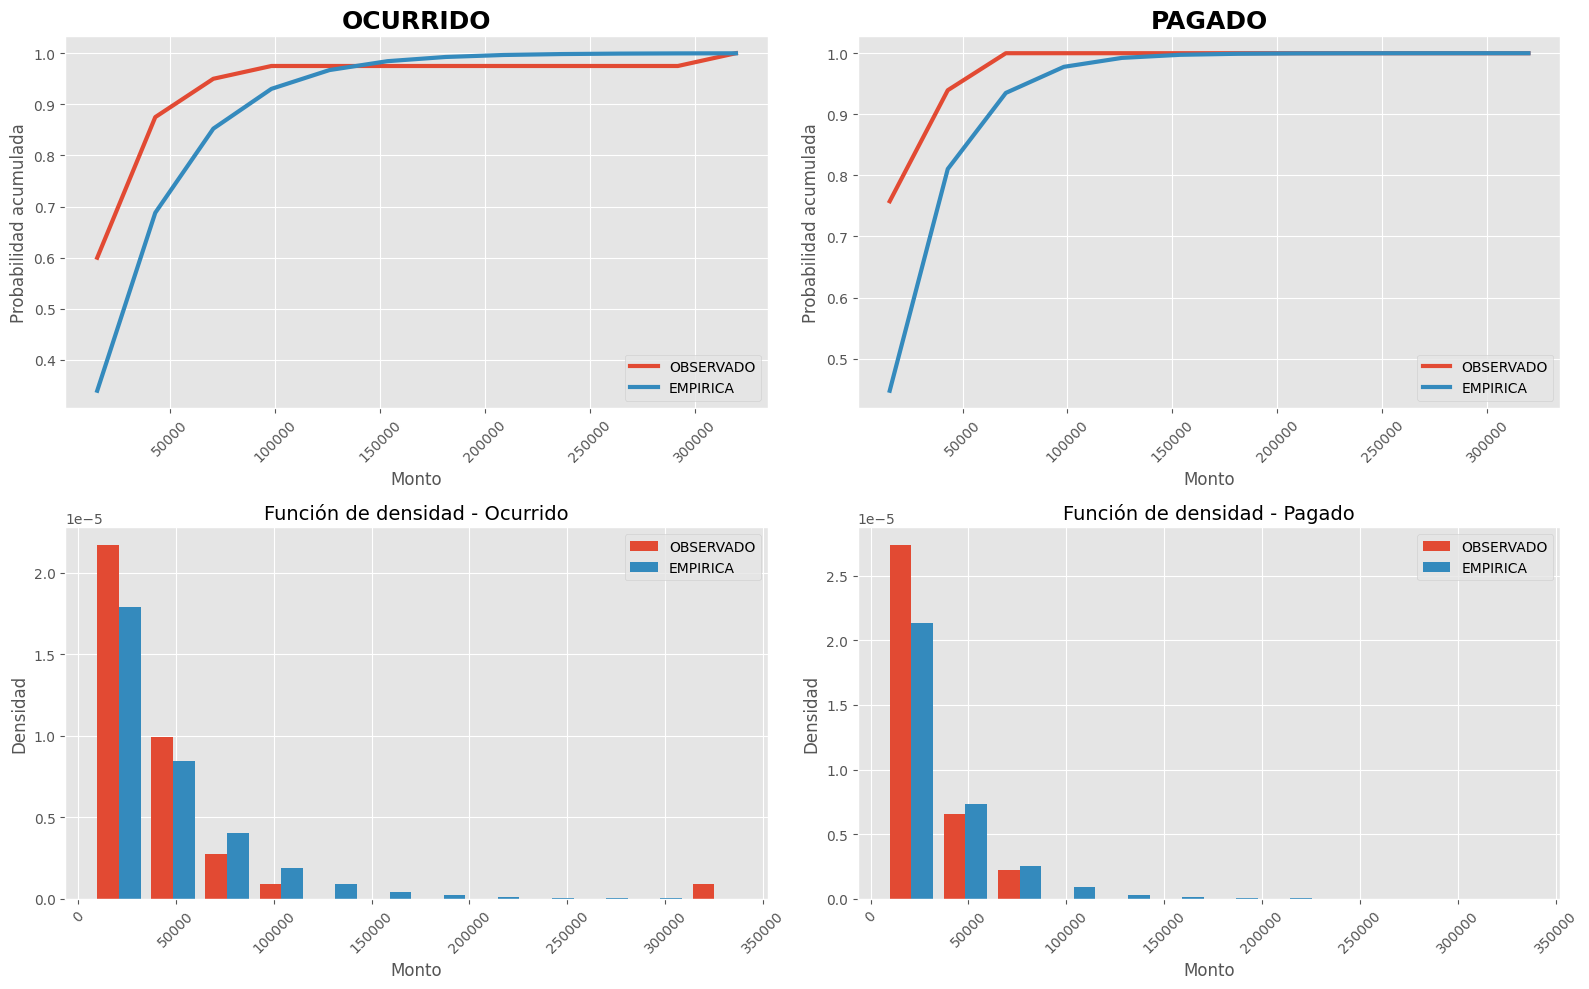

In [9]:
# ============================================
# GRAFICAS DISTRIBUCION EMPIRICA VS OBSERVADA
# ============================================

# Estilo ggplot de R
plt.style.use("ggplot")

# Datos

x_ocurrida = []

x_pagada = []

for _, row in df_xaprox.iterrows():
    
    for anio in anios:
        
        xo = row.get(
            f"XAPROX_OCURRIDA_{anio}",
            0
        )
        
        xp = row.get(
            f"XAPROX_PAGADA_{anio}",
            0
        )
        
        if xo > 0:
            x_ocurrida.append(xo)
        
        if xp > 0:
            x_pagada.append(xp)

x_ocurrida = np.array(x_ocurrida)

x_pagada = np.array(x_pagada)

# Intervalos del histograma

bins = np.histogram_bin_edges(
    np.concatenate([x_ocurrida, x_pagada]),
    bins=12
)

# Distrubución Empirica

hist_occ, edges = np.histogram(
    x_ocurrida,
    bins=bins,
    density=True
)

hist_pag, _ = np.histogram(
    x_pagada,
    bins=bins,
    density=True
)

# Distrubución Exponencial

lambda_occ = 1 / np.mean(x_ocurrida)

lambda_pag = 1 / np.mean(x_pagada)

# Centros

centros = (edges[:-1] + edges[1:]) / 2

# Densidad

dens_occ = expon.pdf(
    centros,
    scale=1/lambda_occ
)

dens_pag = expon.pdf(
    centros,
    scale=1/lambda_pag
)

# Acumulada

cdf_occ = expon.cdf(
    centros,
    scale=1/lambda_occ
)

cdf_pag = expon.cdf(
    centros,
    scale=1/lambda_pag
)

# Empirica acumulada

emp_occ = np.cumsum(hist_occ)

emp_occ = emp_occ / emp_occ.max()

emp_pag = np.cumsum(hist_pag)

emp_pag = emp_pag / emp_pag.max()


# Gráficas

fig, axs = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

# Ocurrido acumulada

axs[0,0].plot(
    centros,
    emp_occ,
    linewidth=3,
    label="OBSERVADO"
)

axs[0,0].plot(
    centros,
    cdf_occ,
    linewidth=3,
    label="EMPIRICA"
)

axs[0,0].set_title(
    "OCURRIDO",
    fontsize=18,
    fontweight="bold"
)

axs[0,0].set_xlabel(
    "Monto"
)

axs[0,0].set_ylabel(
    "Probabilidad acumulada"
)

axs[0,0].legend()

# Pagado acumulada

axs[0,1].plot(
    centros,
    emp_pag,
    linewidth=3,
    label="OBSERVADO"
)

axs[0,1].plot(
    centros,
    cdf_pag,
    linewidth=3,
    label="EMPIRICA"
)

axs[0,1].set_title(
    "PAGADO",
    fontsize=18,
    fontweight="bold"
)

axs[0,1].set_xlabel(
    "Monto"
)

axs[0,1].set_ylabel(
    "Probabilidad acumulada"
)

axs[0,1].legend()

# Ocurrido densidad

width = np.diff(edges)

axs[1,0].bar(
    centros,
    hist_occ,
    width=width*0.4,
    label="OBSERVADO"
)

axs[1,0].bar(
    centros + width*0.4,
    dens_occ,
    width=width*0.4,
    label="EMPIRICA"
)

axs[1,0].set_title(
    "Función de densidad - Ocurrido",
    fontsize=14
)

axs[1,0].set_xlabel(
    "Monto"
)

axs[1,0].set_ylabel(
    "Densidad"
)

axs[1,0].legend()

# Pagado Densidad

axs[1,1].bar(
    centros,
    hist_pag,
    width=width*0.4,
    label="OBSERVADO"
)

axs[1,1].bar(
    centros + width*0.4,
    dens_pag,
    width=width*0.4,
    label="EMPIRICA"
)

axs[1,1].set_title(
    "Función de densidad - Pagado",
    fontsize=14
)

axs[1,1].set_xlabel(
    "Monto"
)

axs[1,1].set_ylabel(
    "Densidad"
)

axs[1,1].legend()

# Formato

for ax in axs.flat:
    
    ax.grid(True)
    
    ax.tick_params(
        axis='x',
        rotation=45
    )

plt.tight_layout()

plt.show()

,DEDUCIBLE,P(X<=x),P(X>x),P(X=x),"E[P_d,SA(X)]",f,f_pct
0,500,0.013454,0.986546,0.000027,36324.624013,0.986513,98.651328
1,1000,0.026727,0.973273,0.000026,35834.707878,0.973208,97.320802
2,1500,0.039822,0.960178,0.000026,35351.391790,0.960082,96.008200
3,2000,0.052740,0.947260,0.000026,34874.545589,0.947132,94.713169
4,2500,0.065485,0.934515,0.000025,34404.168048,0.934357,93.435706
5,3000,0.078058,0.921942,0.000025,33940.033272,0.921752,92.175197
6,3500,0.090462,0.909538,0.000025,33482.102008,0.909315,90.931535
7,4000,0.102699,0.897301,0.000024,33030.293760,0.897045,89.704503
8,4500,0.114771,0.885229,0.000024,32584.559640,0.884940,88.493967
9,5000,0.126681,0.873319,0.000024,32144.783933,0.872996,87.299613


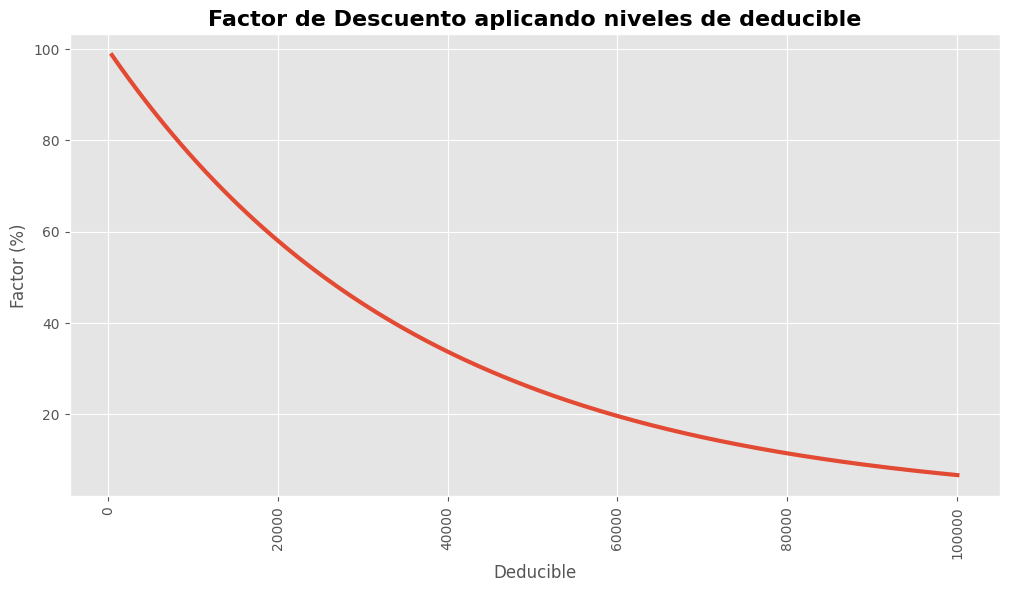

In [10]:
# ============================================
# FACTOR DE DESCUENTO
# EXPONENCIAL
# ============================================

from scipy.stats import expon
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# AJUSTE EXPONENCIAL
# ============================================

loc, scale = expon.fit(
    x_ocurrida,
    floc=0
)

# ============================================
# SIMULACION
# ============================================

n_sim = 500000

simulaciones = expon.rvs(
    loc=loc,
    scale=scale,
    size=n_sim
)

# ============================================
# MEDIA ORIGINAL
# ============================================

media_original = np.mean(
    simulaciones
)

# ============================================
# DEDUCIBLES
# ============================================

deducibles = np.arange(
    500,
    100001,
    500
)

# ============================================
# TABLA
# ============================================

filas_descuento = []

for d in deducibles:
    
    # Probabilidades
    
    p_menor = expon.cdf(
        d,
        loc=loc,
        scale=scale
    )
    
    p_mayor = 1 - p_menor
    
    p_igual = expon.pdf(
        d,
        loc=loc,
        scale=scale
    )
    
    # Pago con deducible
    
    pagos = np.maximum(
        simulaciones - d,
        0
    )
    
    # Esperanza
    
    esperanza = np.mean(
        pagos
    )
    
    # Factor
    
    factor = (
        esperanza / media_original
    )
    
    filas_descuento.append({
        "DEDUCIBLE": d,
        "P(X<=x)": p_menor,
        "P(X>x)": p_mayor,
        "P(X=x)": p_igual,
        "E[P_d,SA(X)]": esperanza,
        "f": factor
    })

# ============================================
# DATAFRAME
# ============================================

df_descuento = pd.DataFrame(
    filas_descuento
)

# ============================================
# FORMATO
# ============================================

df_descuento["f_pct"] = (
    df_descuento["f"] * 100
)

# ============================================
# MOSTRAR TABLA
# ============================================

display(
    df_descuento.head(20)
)

# ============================================
# GRAFICA
# ============================================

plt.style.use("ggplot")

plt.figure(figsize=(12,6))

plt.plot(
    df_descuento["DEDUCIBLE"],
    df_descuento["f_pct"],
    linewidth=3
)

plt.title(
    "Factor de Descuento aplicando niveles de deducible",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Deducible"
)

plt.ylabel(
    "Factor (%)"
)

plt.xticks(
    rotation=90
)

plt.grid(True)

plt.show()

---
## 5. Procedimientos de la prima de tarifa


- Gastos de administración  
- Gastos de adquisición  
- Margen de utilidad  

$$
Prima\ de\ Tarifa
=
Prima\ de\ Riesgo
+
Gastos\ de\ Administración
+
Gastos\ de\ Adquisición
+
Margen\ de\ Utilidad
$$

$$
Prima\ de\ Riesgo
=
SA \times CR
$$

Generalmente los gastos se expresan en términos de la denominada prima de tarifa.

$$
PT
=
PR
+
\%Adm \times PT
+
\%Adq \times PT
+
\%Mu \times PT
$$

$$
\%Gastos\ de\ Administración
=
\frac{
Costo\ de\ Operación
}{
Prima\ Emitida
}
$$

$$
\%Gastos\ de\ Adquisición
=
\frac{
Gasto\ de\ Adquisición
}{
Prima\ Emitida
}
$$

$$
PT
=
PR
+
[\%Adm + \%Adq + \%Mu] \times PT
$$

$$
PT
=
\frac{
PR
}{
1 - [\%Adm + \%Adq + \%Mu]
}
$$

### Cargos adicionales que se hacen

### Derechos de póliza

Se cobra como un gasto directo.

- Papeles inmediatos del seguro  
  (Póliza, contenedores, papelería, etc.)

### Recargo por pago fraccionado para financiar la prima

Si el asegurado decide realizar pagos iguales de monto $(R)$ para cubrir el costo del seguro, entonces la compañía financia el pago fraccionado utilizando para ello una tasa de interés $(i)$.

### El factor $(f)$

$$
f
=
\frac{
m
}{
\sum_{k=0}^{m-1}
\left(
1+\frac{j}{m}
\right)^{-k}
}
$$

Dicho factor $(f)$ cumple con:

$$
R
=
\frac{
PyG
}{
m
}
$$

$$
PyG
=
PyG_0 \times f
$$

$$
\sum_{k=0}^{m-1}
R
*
\left(
1+\frac{j}{m}
\right)^{-k}
=
PyG
$$

donde:

- $(\frac{j}{m})$ = tasa efectiva mensual  
- $(j)$ = tasa de interés anual

In [11]:
# ============================================
# CALCULO DE PRIMA DE TARIFA
# ============================================

# Supuestos tecnicos

gasto_admin = 0.20

gasto_adquisicion = 0.05

margen_utilidad = 0.06

# Tasa anual para recargo financiero

j = 0.08

# Numero de pagos fraccionados

m = 12

# Factor de financiamiento

factor_financiero = (
    
    m /
    
    sum(
        (
            1 + (j / m)
        ) ** (-k)
        
        for k in range(m)
    )
)

# Porcentaje total

cargos = (gasto_admin + gasto_adquisicion + margen_utilidad )

# Calculo de prima de tarifa

filas_tarifa = []

for _, row in df_metricas.iterrows():
    
    fila = {
        "COBERTURA": row["COBERTURA"],
        "TIPO DE BIEN": row["TIPO DE BIEN"]
    }
    
    for anio in anios:
        
        # Cuota de riesgo
        
        cr = row.get(
            f"CR_MAX_{anio}",
            0
        )

        # Prima de riesgo
        
        pr = row.get(
            f"PR_OCURRIDA_{anio}",
            0
        )
        
        # Validacion de nulos
        
        cr = (
            0
            if pd.isna(cr)
            else cr
        )
        
        pr = (
            0
            if pd.isna(pr)
            else pr
        )
        
        # Validacion de negativos
        
        # En seguros no puede existir:
        # prima negativa
        # cuota negativa
        
        pr = max(pr, 0)
        
        cr = max(cr, 0)
        
        # Validacion de experiencia
        
        # Si no existe experiencia
        # dejamos tarifa en cero
        
        if pr == 0:
            
            pt = 0
            
            pt_recargo = 0
            
            recibo_mensual = 0
            
            gasto_admin_pt = 0
            
            gasto_adq_pt = 0
            
            margen_utilidad_pt = 0
        
        else:
            
            # Prima de tarifa
            
            # Formula:
            #
            # PT = PR / (1 - gastos)
            
            pt = (
                
                pr /
                
                (1 - cargos)
                
            )
            
            # Recargo financiero
            
            pt_recargo = (
                
                pt *
                factor_financiero
                
            )

            # Recibo mensual
            
            recibo_mensual = (
                
                pt_recargo / m
                
            )
            
            # Desgloce de datos
            
            gasto_admin_pt = (
                
                pt *
                gasto_admin
                
            )
            
            gasto_adq_pt = (
                
                pt *
                gasto_adquisicion
                
            )
            
            margen_utilidad_pt = (
                
                pt *
                margen_utilidad
                
            )
        
        # Relacion prima - cuota
        
        # Prima por millar
        
        prima_millar = (
            
            cr *
            (1 / (1 - cargos))
            
        )
        
        # Recargo financiero
        
        recargo_pct = (
            
            (
                pt_recargo / pt
            ) - 1
            
            if pt != 0
            else 0
        )
        
        # Guardamos los resultados
        
        fila[f"CR_{anio}"] = cr
        
        fila[f"PR_{anio}"] = pr
        
        fila[f"PT_{anio}"] = pt
        
        fila[f"PT_RECARGO_{anio}"] = pt_recargo
        
        fila[f"RECIBO_MENSUAL_{anio}"] = recibo_mensual
        
        fila[f"PRIMA_MILLAR_{anio}"] = prima_millar
        
        fila[f"RECARGO_PCT_{anio}"] = recargo_pct
        
        fila[f"GASTO_ADMIN_{anio}"] = gasto_admin_pt
        
        fila[f"GASTO_ADQ_{anio}"] = gasto_adq_pt
        
        fila[f"MARGEN_UTILIDAD_{anio}"] = margen_utilidad_pt
    
    filas_tarifa.append(fila)
    
# Dataframe

df_prima_tarifa = pd.DataFrame(
    filas_tarifa
)

# Redondeo

columnas_numericas = (
    
    df_prima_tarifa
    .select_dtypes(include=[np.number])
    .columns
    
)

df_prima_tarifa[columnas_numericas] = (
    
    df_prima_tarifa[columnas_numericas]
    .round(6)
    
)


columnas_finales = [
    
    "COBERTURA",
    "TIPO DE BIEN"
]

for anio in anios:
    
    columnas_finales.extend([
        
        f"CR_{anio}",
        
        f"PR_{anio}",
        
        f"PT_{anio}",
        
        f"PT_RECARGO_{anio}",
        
        f"RECIBO_MENSUAL_{anio}",
        
        f"PRIMA_MILLAR_{anio}",
        
        f"RECARGO_PCT_{anio}",
        
        f"GASTO_ADMIN_{anio}",
        
        f"GASTO_ADQ_{anio}",
        
        f"MARGEN_UTILIDAD_{anio}"
    ])

df_prima_tarifa = (
    
    df_prima_tarifa[
        columnas_finales
    ]
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    "{:,.6f}".format
)


display(df_prima_tarifa)

,COBERTURA,TIPO DE BIEN,CR_2020,PR_2020,PT_2020,PT_RECARGO_2020,RECIBO_MENSUAL_2020,PRIMA_MILLAR_2020,RECARGO_PCT_2020,GASTO_ADMIN_2020,GASTO_ADQ_2020,MARGEN_UTILIDAD_2020,CR_2021,PR_2021,PT_2021,PT_RECARGO_2021,RECIBO_MENSUAL_2021,PRIMA_MILLAR_2021,RECARGO_PCT_2021,GASTO_ADMIN_2021,GASTO_ADQ_2021,MARGEN_UTILIDAD_2021,CR_2022,PR_2022,PT_2022,PT_RECARGO_2022,RECIBO_MENSUAL_2022,PRIMA_MILLAR_2022,RECARGO_PCT_2022,GASTO_ADMIN_2022,GASTO_ADQ_2022,MARGEN_UTILIDAD_2022,CR_2023,PR_2023,PT_2023,PT_RECARGO_2023,RECIBO_MENSUAL_2023,PRIMA_MILLAR_2023,RECARGO_PCT_2023,GASTO_ADMIN_2023,GASTO_ADQ_2023,MARGEN_UTILIDAD_2023,CR_2024,PR_2024,PT_2024,PT_RECARGO_2024,RECIBO_MENSUAL_2024,PRIMA_MILLAR_2024,RECARGO_PCT_2024,GASTO_ADMIN_2024,GASTO_ADQ_2024,MARGEN_UTILIDAD_2024
0,Todo Riesgo,Edificio,0.030287,77.027248,111.633693,115.758353,9.646529,0.043894,0.036948,22.326739,5.581685,6.698022,0.027900,342.571814,496.480890,514.824946,42.902079,0.040435,0.036948,99.296178,24.824044,29.788853,0.020918,128.884693,186.789411,193.690936,16.140911,0.030316,0.036948,37.357882,9.339471,11.207365,0.044199,165.798568,240.287780,249.165971,20.763831,0.064056,0.036948,48.057556,12.014389,14.417267,0.047255,181.500180,263.043739,272.762721,22.730227,0.068486,0.036948,52.608748,13.152187,15.782624
1,Todo Riesgo,Contenidos,0.060876,26.700511,38.696393,40.126153,3.343846,0.088226,0.036948,7.739279,1.934820,2.321784,0.021616,36.183541,52.439915,54.377473,4.531456,0.031327,0.036948,10.487983,2.621996,3.146395,0.017255,34.176860,49.531681,51.361785,4.280149,0.025007,0.036948,9.906336,2.476584,2.971901,0.069712,52.166816,75.604080,78.397512,6.533126,0.101032,0.036948,15.120816,3.780204,4.536245,0.061846,47.762835,69.221500,71.779107,5.981592,0.089632,0.036948,13.844300,3.461075,4.153290
2,Todo Riesgo,Contenidos y Edificio,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008264,622.165493,901.689120,935.004875,77.917073,0.011977,0.036948,180.337824,45.084456,54.101347,0.002133,5.910906,8.566531,8.883048,0.740254,0.003091,0.036948,1.713306,0.428327,0.513992
3,"Incendio, rayo y explosión",Edificio,0.000708,86.106151,124.791523,129.402341,10.783528,0.001026,0.036948,24.958305,6.239576,7.487491,0.037524,90.035786,130.486646,135.307888,11.275657,0.054382,0.036948,26.097329,6.524332,7.829199,0.224426,"1,106.311776","1,603.350400","1,662.591250",138.549271,0.325255,0.036948,320.670080,80.167520,96.201024,0.070694,204.244544,296.006586,306.943485,25.578624,0.102455,0.036948,59.201317,14.800329,17.760395,0.054630,234.188292,339.403321,351.943650,29.328637,0.079174,0.036948,67.880664,16.970166,20.364199
4,"Incendio, rayo y explosión",Contenidos,0.000460,32.495057,47.094286,48.834333,4.069528,0.000666,0.036948,9.418857,2.354714,2.825657,0.073159,164.740103,238.753772,247.575285,20.631274,0.106027,0.036948,47.750754,11.937689,14.325226,0.060845,51.580207,74.753923,77.515943,6.459662,0.088181,0.036948,14.950785,3.737696,4.485235,0.028730,34.280354,49.681673,51.517319,4.293110,0.041638,0.036948,9.936335,2.484084,2.980900,0.054875,61.374992,88.949263,92.235775,7.686315,0.079528,0.036948,17.789853,4.447463,5.336956
5,"Incendio, rayo y explosión",Contenidos y Edificio,0.040826,602.038609,872.519723,904.757723,75.396477,0.059168,0.036948,174.503945,43.625986,52.351183,0.024183,101.080751,146.493842,151.906520,12.658877,0.035048,0.036948,29.298768,7.324692,8.789631,0.003294,76.675978,111.124605,115.230455,9.602538,0.004775,0.036948,22.224921,5.556230,6.667476,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001503,77.171429,111.842650,115.975030,9.664586,0.002178,0.036948,22.368530,5.592133,6.710559
6,Remoción de Escombros,Edificio,0.000082,4.331194,6.277093,6.509020,0.542418,0.000119,0.036948,1.255419,0.313855,0.376626,0.03303

---
## 6. Cálculo de la cuota de riesgo en función del estado

### Cartera global: Características de riesgo (Entidad Federativa donde se suscribe el riesgo)

La cuota de riesgo por estado se obtiene a partir de la cuota global, ajustada mediante un factor geográfico que refleja el comportamiento siniestral de cada Entidad Federativa:

$$
CR^{Estado} = CR^{Global} \cdot f^{Estado}
$$

Donde la cuota de riesgo ocurrida y pagada por estado se calculan como:

$$
CR_{Ocurrida,\,i,\,Estado\ k} = \frac{\text{Monto Siniestros Ocurridos}_{i,j,\,Estado\ k}}{\text{Suma Asegurada Expuesta}_{i,j,\,Estado\ k}} \cdot 1{,}000
$$

$$
CR_{Pagada,\,i} = \frac{\text{Monto Siniestros Pagados}_{i,j,\,m\ Estado\ k}}{\text{Suma Asegurada Expuesta}_{i,j,\,Estado\ k}} \cdot 1{,}000
$$

El factor geográfico se define como:

$$
f^{Estado} = \frac{CR^{Estado}}{CR^{Global}}
$$

Donde $f_g^Z$ es el **factor de recargo o de descuento** por zona geográfica.

---

### Selección de cuota por estado

Dado que no todos los estados poseen información y en algún caso la siniestralidad es negativa, el criterio de selección del factor es:

$$
f_{edo} =
\begin{cases}
\text{Cuota Global} & \text{si } \dfrac{\text{Cuota Estado}}{\text{Cuota Global}} \leq 0 \\[10pt]
\dfrac{\text{Cuota Estado}}{\text{Cuota Global}} & \text{si } \dfrac{\text{Cuota Estado}}{\text{Cuota Global}} > 0
\end{cases}
$$

In [12]:
# ============================================
# CUOTA DE RIESGO GLOBAL
# ============================================

df_cr_global = df_metricas[["COBERTURA", "TIPO DE BIEN"]].copy()

df_cr_global["CR_GLOBAL"] = df_metricas[
    [f"CR_MAX_{a}" for a in anios]
].replace(0, np.nan).mean(axis=1)

# ============================================
# DETECTAR COLUMNA DE ENTIDAD FEDERATIVA
# ============================================

col_entidad_sin = next(
    (c for c in siniestros.columns if "ENTIDAD" in c.upper() or "ESTADO" in c.upper()),
    None
)

col_entidad_suma = next(
    (c for c in suma.columns if "ENTIDAD" in c.upper() or "ESTADO" in c.upper()),
    None
)

print("Columna entidad en siniestros :", col_entidad_sin)
print("Columna entidad en suma       :", col_entidad_suma)

if col_entidad_sin is None:
    print("\n⚠️  No se encontró columna de entidad/estado en siniestros.")
    print("Columnas disponibles:", siniestros.columns.tolist())

Columna entidad en siniestros : ENTIDAD
Columna entidad en suma       : ENTIDAD


In [13]:
# ============================================
# FILTRO DE SINIESTROS POR ESTADO
# ============================================

filtro_sin_edo = siniestros[

    # MONEDA
    siniestros["MONEDA"].astype(str).str.contains(
        "Nacional", case=False, na=False
    ) &

    # Giro
    siniestros["GIRO LA UBICACIÓN"].astype(str).str.contains(
        "Casa", case=False, na=False
    ) &

    # Tipo primer riesgo
    siniestros["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning", case=False, na=False
    ) &

    # Tipo de bien
    siniestros["TIPO DE BIEN"].astype(str).str.contains(
        "Contenidos|Edificio", case=False, na=False
    ) &

    # Cobertura
    siniestros["COBERTURA"].astype(str).str.contains(
        "Incendio|Remoción|Gastos Extras|Todo riesgo",
        case=False, na=False
    )
].copy()

print(f"Registros de siniestros con filtro: {len(filtro_sin_edo)}")
print(f"Columna entidad en siniestros: {col_entidad_sin}")

Registros de siniestros con filtro: 11297
Columna entidad en siniestros: ENTIDAD


In [14]:
# ============================================
# FILTRO DE SUMA ASEGURADA POR ESTADO
# ============================================

filtro_suma_edo = suma[

    # Giro
    suma["GIRO"].astype(str).str.contains(
        "Casa", case=False, na=False
    ) &

    # Tipo primer riesgo
    suma["TIPO PRIMER RIESGO"].astype(str).str.contains(
        "Ning", case=False, na=False
    ) &

    # Tipo de bien
    suma["TIPO DE BIEN"].astype(str).str.contains(
        "Contenidos|Edificio", case=False, na=False
    ) &

    # Cobertura
    suma["COBERTURA "].astype(str).str.contains(
        "Incendio|Remoción|Gastos Extras|Todo riesgo",
        case=False, na=False
    )
].copy()

print(f"Registros de suma asegurada con filtro: {len(filtro_suma_edo)}")
print(f"Columna entidad en suma asegurada: {col_entidad_suma}")

Registros de suma asegurada con filtro: 2386
Columna entidad en suma asegurada: ENTIDAD


In [15]:
# ============================================
# CUOTA DE RIESGO POR ESTADO
# ============================================

coberturas_edo = filtro_sin_edo["COBERTURA"].unique()
tipos_edo      = filtro_sin_edo["TIPO DE BIEN"].unique()
estados        = sorted(filtro_sin_edo[col_entidad_sin].dropna().unique())

filas_edo = []

for estado in estados:

    for cobertura in coberturas_edo:

        for tipo in tipos_edo:

            # ---------- Siniestros ----------
            mask_sin = (
                (filtro_sin_edo[col_entidad_sin] == estado) &
                (filtro_sin_edo["COBERTURA"]     == cobertura) &
                (filtro_sin_edo["TIPO DE BIEN"]  == tipo)
            )
            temp_sin = filtro_sin_edo[mask_sin]

            # ---------- Suma Asegurada Expuesta ----------
            mask_sa = (
                (filtro_suma_edo[col_entidad_suma] == estado) &
                (filtro_suma_edo["COBERTURA "]     == cobertura) &
                (filtro_suma_edo["TIPO DE BIEN"]   == tipo)
            )
            temp_sa = filtro_suma_edo[mask_sa]

            if temp_sin.empty and temp_sa.empty:
                continue

            monto_ocurrido = temp_sin["MONTO DE SINIESTRO"].sum()
            monto_pagado   = temp_sin["MONTO PAGADO"].sum()
            sae_total      = temp_sa["SUMA ASEGURADA EXPUESTA"].sum()

            cr_ocurrida = (monto_ocurrido / sae_total * 1000) if sae_total != 0 else 0
            cr_pagada   = (monto_pagado   / sae_total * 1000) if sae_total != 0 else 0
            cr_max      = max(cr_ocurrida, cr_pagada)

            filas_edo.append({
                "ENTIDAD"        : estado,
                "COBERTURA"      : cobertura,
                "TIPO DE BIEN"   : tipo,
                "MONTO_OCURRIDO" : monto_ocurrido,
                "MONTO_PAGADO"   : monto_pagado,
                "SAE"            : sae_total,
                "CR_OCURRIDA"    : cr_ocurrida,
                "CR_PAGADA"      : cr_pagada,
                "CR_MAX"         : cr_max,
            })

df_cr_edo = pd.DataFrame(filas_edo)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.6f}".format)
display(df_cr_edo)

,ENTIDAD,COBERTURA,TIPO DE BIEN,MONTO_OCURRIDO,MONTO_PAGADO,SAE,CR_OCURRIDA,CR_PAGADA,CR_MAX
0,Aguascalientes,"Incendio, rayo y explosión",Edificio,"807,150.170000","656,887.210000",42414902182,0.019030,0.015487,0.019030
1,Aguascalientes,"Incendio, rayo y explosión",Contenidos,"418,844.030000","419,945.790000",11995058615,0.034918,0.035010,0.035010
2,Aguascalientes,"Incendio, rayo y explosión",Contenidos y Edificio,"27,010.000000",0.000000,1275394985,0.021178,0.000000,0.021178
3,Aguascalientes,Todo Riesgo,Edificio,"609,125.650000","219,325.730000",42306764962,0.014398,0.005184,0.014398
4,Aguascalientes,Todo Riesgo,Contenidos,"265,795.700000","213,931.570000",11523981644,0.023065,0.018564,0.023065
...,...,...,...,...,...,...,...,...,...
273,Zacatecas,Todo Riesgo,Edificio,"70,412.710000","70,412.710000",4720024400,0.014918,0.014918,0.014918
274,Zacatecas,Todo Riesgo,Contenidos,0.000000,0.000000,1349247530,0.000000,0.000000,0.000000
275,Zacatecas,Remoción de Escombros,Edificio,0.000000,0.000000,334604451,0.000000,0.000000,0.000000
276,Zacatecas,Remoción de Escombros,Contenidos,0.000000,0.000000,118113633,0.000000,0.000000,0.000000


### Factor Geográfico

El factor geográfico $f^{Estado}$ se calcula como el cociente entre la cuota de riesgo de cada entidad federativa y la cuota global. Cuando la cuota por estado es nula o negativa, se asigna el factor global (equivalente a $f_{edo} = 1$).

In [16]:
# ============================================
# FACTOR GEOGRÁFICO POR ESTADO
# ============================================

# Unimos CR estado con CR global
df_factor_geo = df_cr_edo.merge(
    df_cr_global[["COBERTURA", "TIPO DE BIEN", "CR_GLOBAL"]],
    on=["COBERTURA", "TIPO DE BIEN"],
    how="left"
)

# Calcular factor: CR_Estado / CR_Global
# Criterio de selección:
#   - Si CR_Global <= 0 o el cociente <= 0 → factor = 1 (cuota global)
#   - Si el cociente > 0                   → factor = CR_Estado / CR_Global

def calcular_factor(row):

    cr_global = row["CR_GLOBAL"]
    cr_estado = row["CR_MAX"]

    if pd.isna(cr_global) or cr_global == 0:
        return 1.0

    cociente = cr_estado / cr_global

    if cociente <= 0:
        return 1.0
    else:
        return cociente

df_factor_geo["FACTOR_GEO"] = df_factor_geo.apply(
    calcular_factor, axis=1
)

# CR específica = CR_Global * Factor_Geo
df_factor_geo["CR_ESPECIFICA"] = (
    df_factor_geo["CR_GLOBAL"] * df_factor_geo["FACTOR_GEO"]
)

pd.set_option("display.max_columns", None)
display(
    df_factor_geo[[
        "ENTIDAD", "COBERTURA", "TIPO DE BIEN",
        "CR_MAX", "CR_GLOBAL", "FACTOR_GEO", "CR_ESPECIFICA"
    ]]
)

,ENTIDAD,COBERTURA,TIPO DE BIEN,CR_MAX,CR_GLOBAL,FACTOR_GEO,CR_ESPECIFICA
0,Aguascalientes,"Incendio, rayo y explosión",Edificio,0.019030,0.077596,0.245242,0.019030
1,Aguascalientes,"Incendio, rayo y explosión",Contenidos,0.035010,0.043614,0.802728,0.035010
2,Aguascalientes,"Incendio, rayo y explosión",Contenidos y Edificio,0.021178,0.017452,1.213516,0.021178
3,Aguascalientes,Todo Riesgo,Edificio,0.014398,0.034112,0.422077,0.014398
4,Aguascalientes,Todo Riesgo,Contenidos,0.023065,0.046261,0.498576,0.023065
...,...,...,...,...,...,...,...
273,Zacatecas,Todo Riesgo,Edificio,0.014918,0.034112,0.437322,0.014918
274,Zacatecas,Todo Riesgo,Contenidos,0.000000,0.046261,1.000000,0.046261
275,Zacatecas,Remoción de Escombros,Edificio,0.000000,0.072001,1.000000,0.072001
276,Zacatecas,Remoción de Escombros,Contenidos,0.000000,0.012588,1.000000,0.012588


In [17]:
# ============================================
# TABLA RESUMEN: FACTOR POR ESTADO
# FORMATO NOTA TÉCNICA
# ============================================

# Tabla pivot: filas = estados, columnas = cobertura+tipo
df_pivot_factor = df_factor_geo.pivot_table(
    index="ENTIDAD",
    columns=["COBERTURA", "TIPO DE BIEN"],
    values="FACTOR_GEO",
    aggfunc="mean"
)

df_pivot_cr_esp = df_factor_geo.pivot_table(
    index="ENTIDAD",
    columns=["COBERTURA", "TIPO DE BIEN"],
    values="CR_ESPECIFICA",
    aggfunc="mean"
)

print("=" * 60)
print("FACTOR GEOGRÁFICO POR ESTADO (f_edo)")
print("=" * 60)
display(df_pivot_factor.round(6))

print("\n")
print("=" * 60)
print("CUOTA DE RIESGO ESPECÍFICA POR ESTADO (al millar)")
print("=" * 60)
display(df_pivot_cr_esp.round(6))

FACTOR GEOGRÁFICO POR ESTADO (f_edo)


COBERTURA           Gastos Extras para Casa Habitación           \
TIPO DE BIEN                                Contenidos Edificio   
ENTIDAD                                                           
Aguascalientes                                1.000000      NaN   
Baja California                               1.000000 1.000000   
Baja California Sur                           1.000000      NaN   
Campeche                                      1.000000      NaN   
Chiapas                                       1.000000      NaN   
Chihuahua                                     1.000000      NaN   
Ciudad de México                              1.000000      NaN   
Coahuila                                      1.000000      NaN   
Colima                                        1.000000      NaN   
Durango                                       1.000000      NaN   
Guanajuato                                    1.000000      NaN   
Guerrero                                      1.000000      NaN   
Hidalgo                                       1.000000      NaN   
Jalisco                                       1.000000      NaN   
Mexico                                        1.000000      NaN   
Michoacán                                     1.000000      NaN   
Morelos                                       1.000000      NaN   
Nayarit                                       1.000000      NaN   
Nuevo Leon                                    8.025235 1.000000   
Oaxaca                                        1.000000      NaN   
Puebla                                        1.000000      NaN   
Querétaro                                     1.000000      NaN   
Quintana Roo                                  1.000000      NaN   
San Luis Potosí                               1.000000      NaN   
Sinaloa                                       1.000000      NaN   
Sonora                                        1.000000      NaN   
Tabasco                                       1.000000      NaN   
Tamaulipas                                    1.000000      NaN   
Tlaxcala                                      1.000000      NaN   
Veracruz                                      1.000000      NaN   
Yucatán                                       1.000000      NaN   
Zacatecas                                     1.000000      NaN   

COBERTURA           Incendio, rayo y explosión                        \
TIPO DE BIEN                        Contenidos Contenidos y Edificio   
ENTIDAD                                                                
Aguascalientes                        0.802728              1.213516   
Baja California                       1.012821              1.000000   
Baja California Sur                   0.057753              1.397366   
Campeche                              0.869530                   NaN   
Chiapas                               1.875704                   NaN   
Chihuahua                             0.937236              1.000000   
Ciudad de México                      0.163630              1.000000   
Coahuila                              0.003743              1.000000   
Colima                                0.755653              1.000000   
Durango                               1.325358                   NaN   
Guanajuato                            0.847838              1.000000   
Guerrero                              0.856553              1.000000   
Hidalgo                               0.522655              1.000000   
Jalisco                               8.576163              1.000000   
Mexico                                0.958878              1.000000   
Michoacán                             0.765630             18.793979   
Morelos                               1.335761                   NaN   
Nayarit                               0.107857              1.000000   
Nuevo Leon                            0.842565              2.253683   
Oaxaca                                0.061992                   NaN  



CUOTA DE RIESGO ESPECÍFICA POR ESTADO (al millar)


COBERTURA           Gastos Extras para Casa Habitación  \
TIPO DE BIEN                                Contenidos   
ENTIDAD                                                  
Aguascalientes                                0.012860   
Baja California                               0.012860   
Baja California Sur                           0.012860   
Campeche                                      0.012860   
Chiapas                                       0.012860   
Chihuahua                                     0.012860   
Ciudad de México                              0.012860   
Coahuila                                      0.012860   
Colima                                        0.012860   
Durango                                       0.012860   
Guanajuato                                    0.012860   
Guerrero                                      0.012860   
Hidalgo                                       0.012860   
Jalisco                                       0.012860   
Mexico                                        0.012860   
Michoacán                                     0.012860   
Morelos                                       0.012860   
Nayarit                                       0.012860   
Nuevo Leon                                    0.103203   
Oaxaca                                        0.012860   
Puebla                                        0.012860   
Querétaro                                     0.012860   
Quintana Roo                                  0.012860   
San Luis Potosí                               0.012860   
Sinaloa                                       0.012860   
Sonora                                        0.012860   
Tabasco                                       0.012860   
Tamaulipas                                    0.012860   
Tlaxcala                                      0.012860   
Veracruz                                      0.012860   
Yucatán                                       0.012860   
Zacatecas                                     0.012860   

COBERTURA           Incendio, rayo y explosión                                 \
TIPO DE BIEN                        Contenidos Contenidos y Edificio Edificio   
ENTIDAD                                                                         
Aguascalientes                        0.035010              0.021178 0.019030   
Baja California                       0.044173              0.017452 0.060387   
Baja California Sur                   0.002519              0.024386 0.000776   
Campeche                              0.037923                   NaN 0.033956   
Chiapas                               0.081806                   NaN 0.065223   
Chihuahua                             0.040876              0.017452 0.038717   
Ciudad de México                      0.007137              0.017452 0.034226   
Coahuila                              0.000163              0.017452 0.000309   
Colima                                0.032957              0.017452 0.021050   
Durango                               0.057804                   NaN 0.108581   
Guanajuato                            0.036977              0.017452 0.027778   
Guerrero                              0.037357              0.017452 0.251012   
Hidalgo                               0.022795              0.017452 0.020949   
Jalisco                               0.374038              0.017452 0.134829   
Mexico                                0.041820              0.017452 0.041295   
Michoacán                             0.033392              0.327984 0.020657   
Morelos                               0.058257                   NaN 0.044167   
Nayarit                               0.004704              0.017452 0.018920   
Nuevo Leon                            0.036747              0.039330 0.314952   
Oaxaca                                0.002704                   NaN 0.384980   
Puebla                                0.004914              0.017452 0.197953   
Querétaro                

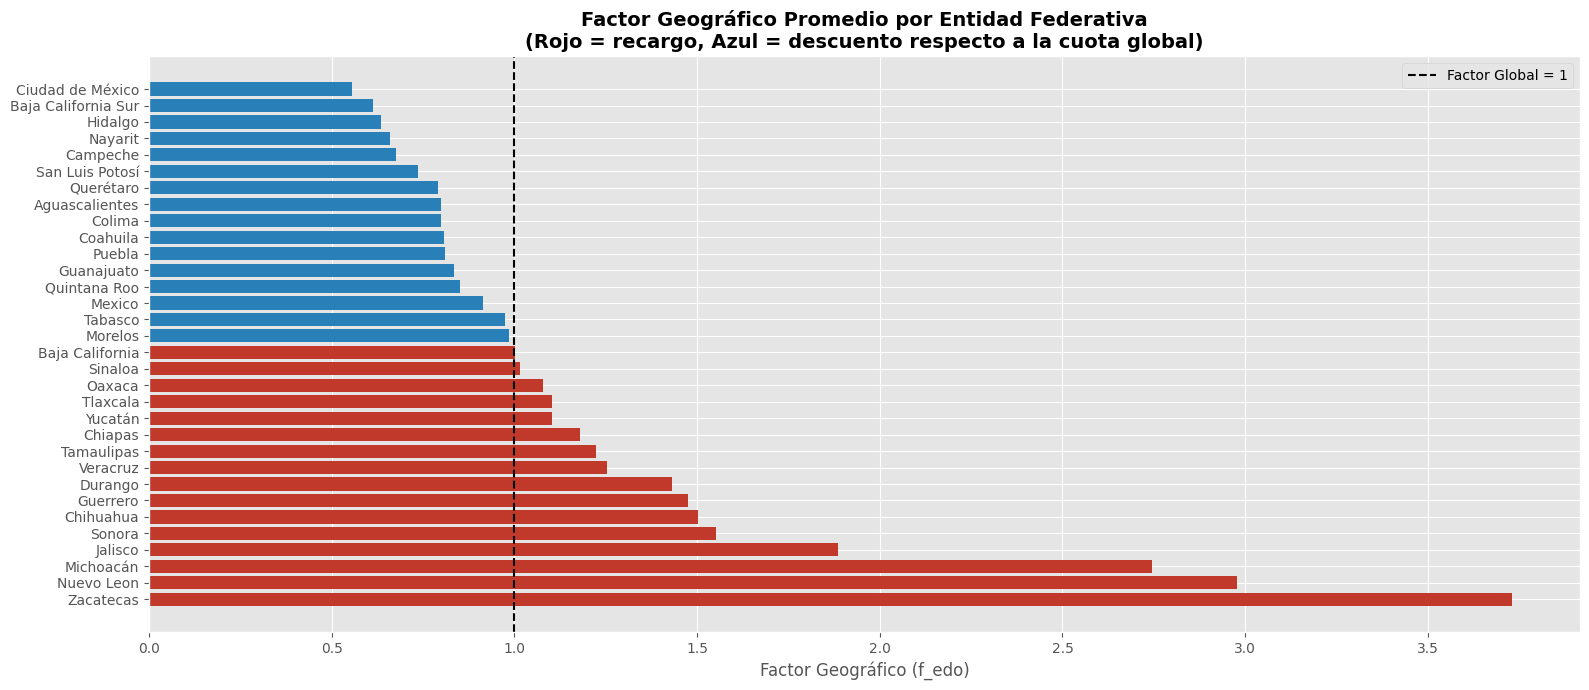

In [18]:
# ============================================
# GRÁFICA: FACTOR GEOGRÁFICO POR ESTADO
# ============================================

plt.style.use("ggplot")

# Promedio de factor por estado (todas coberturas y tipos)
factor_prom_edo = (
    df_factor_geo
    .groupby("ENTIDAD")["FACTOR_GEO"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 7))

colores = [
    "#c0392b" if v > 1 else "#2980b9"
    for v in factor_prom_edo.values
]

ax.barh(
    factor_prom_edo.index,
    factor_prom_edo.values,
    color=colores
)

ax.axvline(
    x=1,
    color="black",
    linewidth=1.5,
    linestyle="--",
    label="Factor Global = 1"
)

ax.set_title(
    "Factor Geográfico Promedio por Entidad Federativa\n"
    "(Rojo = recargo, Azul = descuento respecto a la cuota global)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Factor Geográfico (f_edo)")
ax.legend()
ax.grid(True, axis="x")

plt.tight_layout()
plt.show()

### Cuota de Riesgo Final

La cuota final integra el factor de descuento por deducible y el factor geográfico sobre la cuota global:

$$CR_{Final} = CR^{Global} \cdot f^{Deducible} \cdot f^{Estado}$$

In [19]:
# ============================================
# TABLA FINAL: CUOTA POR ESTADO Y DEDUCIBLE
# ============================================
# Combina el factor de descuento por deducible
# con el factor geográfico por estado,
# para obtener la cuota final de cada combinación.

# Factor de descuento del deducible global (de df_descuento)
# Aquí usamos la cuota global * factor_deducible * factor_geo

# Resumen: CR_FINAL = CR_GLOBAL * f_deducible * f_geo

# Solo mostramos los primeros 20 deducibles como referencia

deducibles_muestra = df_descuento["DEDUCIBLE"].head(20).values

filas_final = []

for _, row_geo in df_factor_geo.iterrows():

    cr_global  = row_geo["CR_GLOBAL"]
    factor_geo = row_geo["FACTOR_GEO"]

    if pd.isna(cr_global) or cr_global == 0:
        continue

    for d in deducibles_muestra:

        # Factor de descuento para ese deducible
        f_ded = df_descuento.loc[
            df_descuento["DEDUCIBLE"] == d, "f"
        ].values

        f_ded = f_ded[0] if len(f_ded) > 0 else 1.0

        cr_final = cr_global * f_ded * factor_geo

        filas_final.append({
            "ENTIDAD"      : row_geo["ENTIDAD"],
            "COBERTURA"    : row_geo["COBERTURA"],
            "TIPO DE BIEN" : row_geo["TIPO DE BIEN"],
            "DEDUCIBLE"    : d,
            "CR_GLOBAL"    : cr_global,
            "F_DEDUCIBLE"  : f_ded,
            "F_GEO"        : factor_geo,
            "CR_FINAL"     : cr_final,
        })

df_cr_final = pd.DataFrame(filas_final)

pd.set_option("display.float_format", "{:,.6f}".format)
pd.set_option("display.max_columns", None)

print(f"Tabla CR final: {df_cr_final.shape[0]} filas x {df_cr_final.shape[1]} columnas")
print(f"(Mostrando primeros 20 registros)\n")
display(df_cr_final.head(20))

Tabla CR final: 5520 filas x 8 columnas
(Mostrando primeros 20 registros)



,ENTIDAD,COBERTURA,TIPO DE BIEN,DEDUCIBLE,CR_GLOBAL,F_DEDUCIBLE,F_GEO,CR_FINAL
0,Aguascalientes,"Incendio, rayo y explosión",Edificio,500,0.077596,0.986513,0.245242,0.018773
1,Aguascalientes,"Incendio, rayo y explosión",Edificio,1000,0.077596,0.973208,0.245242,0.018520
2,Aguascalientes,"Incendio, rayo y explosión",Edificio,1500,0.077596,0.960082,0.245242,0.018270
3,Aguascalientes,"Incendio, rayo y explosión",Edificio,2000,0.077596,0.947132,0.245242,0.018024
4,Aguascalientes,"Incendio, rayo y explosión",Edificio,2500,0.077596,0.934357,0.245242,0.017781
5,Aguascalientes,"Incendio, rayo y explosión",Edificio,3000,0.077596,0.921752,0.245242,0.017541
6,Aguascalientes,"Incendio, rayo y explosión",Edificio,3500,0.077596,0.909315,0.245242,0.017304
7,Aguascalientes,"Incendio, rayo y explosión",Edificio,4000,0.077596,0.897045,0.245242,0.017071
8,Aguascalientes,"Incendio, rayo y explosión",Edificio,4500,0.077596,0.884940,0.245242,0.016840
9,Aguascalientes,"Incendio, rayo y explosión",Edificio,5000,0.077596,0.872996,0.245242,0.016613


---
## Exportación de resultados

Se exportan todos los resultados a un archivo Excel con hojas organizadas por etapa del cálculo, el cual servirá como base para la elaboración del cotizador.

In [22]:
# ============================================
# EXPORTAR RESULTADOS A EXCEL
# ============================================

nombre_salida = "RESULTADOS_NOTA_TECNICA.xlsx"

with pd.ExcelWriter(nombre_salida, engine="openpyxl") as writer:

    # Hoja 1: Métricas globales (frecuencia, severidad, prima, cuota)
    df_metricas.to_excel(
        writer,
        sheet_name="Metricas_Globales",
        index=False
    )

    # Hoja 2: Prima de tarifa
    df_prima_tarifa.to_excel(
        writer,
        sheet_name="Prima_Tarifa",
        index=False
    )

    # Hoja 3: Factor de descuento por deducible
    df_descuento.to_excel(
        writer,
        sheet_name="Factor_Deducible",
        index=False
    )

    # Hoja 4: CR global por cobertura/tipo de bien
    df_cr_global.to_excel(
        writer,
        sheet_name="CR_Global",
        index=False
    )

    # Hoja 5: CR y factor por estado
    df_factor_geo.to_excel(
        writer,
        sheet_name="Factor_Geografico",
        index=False
    )

    # Hoja 6: CR final (estado x deducible)
    df_cr_final.to_excel(
        writer,
        sheet_name="CR_Final_Edo_Deducible",
        index=False
    )

    # Hoja 7: Pivot factor geográfico
    df_pivot_factor.round(6).to_excel(
        writer,
        sheet_name="Pivot_Factor_Geo"
    )

    # Hoja 8: Pivot CR específica por estado
    df_pivot_cr_esp.round(6).to_excel(
        writer,
        sheet_name="Pivot_CR_Especifica"
    )

print(f"Archivo exportado: {nombre_salida}")
print(f"   Hojas generadas:")
print(f"   1. Metricas_Globales")
print(f"   2. Prima_Tarifa")
print(f"   3. Factor_Deducible")
print(f"   4. CR_Global")
print(f"   5. Factor_Geografico")
print(f"   6. CR_Final_Edo_Deducible")
print(f"   7. Pivot_Factor_Geo")
print(f"   8. Pivot_CR_Especifica")

Archivo exportado: RESULTADOS_NOTA_TECNICA.xlsx
   Hojas generadas:
   1. Metricas_Globales
   2. Prima_Tarifa
   3. Factor_Deducible
   4. CR_Global
   5. Factor_Geografico
   6. CR_Final_Edo_Deducible
   7. Pivot_Factor_Geo
   8. Pivot_CR_Especifica
